imports

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.io import read_image

In [33]:
transform=transforms.Compose([
    transforms.ToTensor()
])
train_dataset=datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=transform
)
test_dataset=train_dataset=datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=transform
)

classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

Files already downloaded and verified
Files already downloaded and verified


In [34]:
train_loader=DataLoader(train_dataset, shuffle=True, batch_size=64)
test_loader=DataLoader(test_dataset, shuffle=False, batch_size=64)

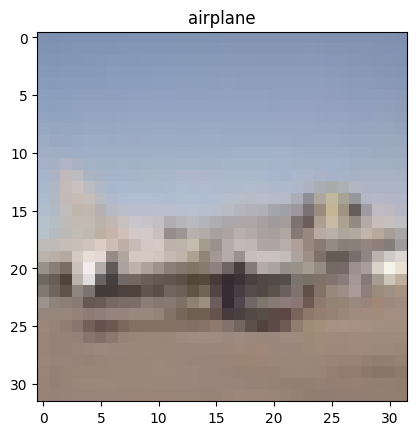

In [35]:
images, labels = next(iter(train_loader))
plt.imshow(images[0].permute(1,2,0))
plt.title(classes[labels[0]])
plt.show()

In [36]:
class CNNmodel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone=nn.Sequential(
            nn.Conv2d(3,16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier=nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*4*4, 128),
            nn.ReLU(),
            nn.Linear(128,10)
        )
    
    def forward(self, x):
        x=self.backbone(x)
        x=self.classifier(x)
        return x
        

In [37]:
device=torch.device('cuda')
model=CNNmodel().to(device)
criteration=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(), lr=0.001)


In [38]:
for epoch in range(50):
    runningloss=0
    for images,labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        prediction=model(images)
        loss=criteration(prediction,labels)
        loss.backward()
        optimizer.step()
        runningloss+=loss.item()
    batchloss=runningloss/len(train_loader)
    print(f'epoch: {epoch+1}/50')
    print(f'loss: {batchloss}')

epoch: 1/50
loss: 2.070510439811998
epoch: 2/50
loss: 1.7817103437557342
epoch: 3/50
loss: 1.5637909811773119
epoch: 4/50
loss: 1.4666512802148322
epoch: 5/50
loss: 1.3701896842118282
epoch: 6/50
loss: 1.3176833322853039
epoch: 7/50
loss: 1.252778956464901
epoch: 8/50
loss: 1.1994727261506828
epoch: 9/50
loss: 1.1484115074394614
epoch: 10/50
loss: 1.0952855424516519
epoch: 11/50
loss: 1.0564523187412578
epoch: 12/50
loss: 1.006383106207392
epoch: 13/50
loss: 0.9618729314986308
epoch: 14/50
loss: 0.9192025019864368
epoch: 15/50
loss: 0.8795703064863849
epoch: 16/50
loss: 0.834837700910629
epoch: 17/50
loss: 0.781998186734072
epoch: 18/50
loss: 0.7454162893021942
epoch: 19/50
loss: 0.7073889321582333
epoch: 20/50
loss: 0.6779200596034907
epoch: 21/50
loss: 0.6206714009783071
epoch: 22/50
loss: 0.601241040002009
epoch: 23/50
loss: 0.5445644018376709
epoch: 24/50
loss: 0.5307421970898938
epoch: 25/50
loss: 0.46335333481336094
epoch: 26/50
loss: 0.4308044982563918
epoch: 27/50
loss: 0.39351

In [39]:
model.eval()
total=0
correct=0
with torch.no_grad():
    for images, labels in test_loader:
        images=images.to(device)
        labels=labels.to(device)
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")


Test Accuracy: 98.61%


In [ ]:
image=read_image("./cat2.png")
transofrmed=transforms.Compose(
    [
        transforms.Resize((32,32)),
        transforms.ConvertImageDtype(torch.float),
    ]
)
timg=transofrmed(image)
timg=timg.to(device).unsqueeze(0)
print(timg.shape)
softmax=nn.Softmax(dim=1)
predict=softmax(model(timg))
print(predict)
classs=torch.argmax(predict, dim=1).item()
print(classes[classs])

torch.Size([1, 3, 32, 32])
tensor([[    0.0009,     0.1328,     0.0000,     0.0020,     0.0000,     0.0006,
             0.0027,     0.0000,     0.0016,     0.8594]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)
truck
